# Saddle-Node Bifurcation Visualization

Interactive visualization of a 2D system approaching a saddle-node bifurcation,
where one eigenvalue of the Jacobian goes to zero.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import warnings
warnings.filterwarnings('ignore')

%matplotlib widget

## System Definition

We use the normal form for a saddle-node bifurcation:

$$\dot{x} = \mu - x^2$$
$$\dot{y} = -y$$

- **μ < 0**: Two fixed points exist (one saddle, one stable node)
- **μ = 0**: Bifurcation point - fixed points collide, one eigenvalue = 0
- **μ > 0**: No fixed points

In [2]:
def vector_field(x, y, mu):
    """Compute the vector field at point (x, y) for parameter mu."""
    dx = mu - x**2
    dy = -y
    return dx, dy


def find_fixed_points(mu):
    """Find fixed points of the system."""
    # Fixed points: mu - x^2 = 0 and y = 0
    # x = ±sqrt(mu) if mu >= 0... wait, let me reconsider
    # Actually for mu - x^2 = 0: x^2 = mu, so x = ±sqrt(mu) if mu > 0
    # For mu < 0: no real solutions
    # 
    # Hmm, that's backwards from what I want. Let me use mu + x^2 = 0 instead
    # which gives x^2 = -mu, so x = ±sqrt(-mu) if mu < 0
    # At mu = 0: single fixed point at origin
    # For mu > 0: no fixed points
    #
    # Actually let's use the standard form: dx/dt = mu + x^2
    # Fixed points: x^2 = -mu, so real solutions when mu <= 0
    # x = ±sqrt(-mu)
    
    if mu < 0:
        x1 = np.sqrt(-mu)
        x2 = -np.sqrt(-mu)
        return [(x1, 0), (x2, 0)]
    elif mu == 0:
        return [(0, 0)]
    else:
        return []


def jacobian_at_fixed_point(x_fp, mu):
    """Compute Jacobian at a fixed point."""
    # J = [[-2x, 0], [0, -1]]
    return np.array([[-2 * x_fp, 0], [0, -1]])


def compute_eigenvalues(x_fp, mu):
    """Compute eigenvalues of Jacobian at fixed point."""
    J = jacobian_at_fixed_point(x_fp, mu)
    return np.linalg.eigvals(J)

In [3]:
# Redefine with correct form
def vector_field(x, y, mu):
    """Vector field: dx/dt = mu + x^2, dy/dt = -y"""
    dx = mu + x**2
    dy = -y
    return dx, dy


def find_fixed_points(mu):
    """Find fixed points. Exist only for mu <= 0."""
    if mu < 0:
        x1 = np.sqrt(-mu)   # Saddle
        x2 = -np.sqrt(-mu)  # Stable node
        return [(x1, 0), (x2, 0)]
    elif np.abs(mu) < 1e-10:
        return [(0, 0)]
    else:
        return []


def jacobian_eigenvalues(x_fp):
    """Eigenvalues of J = [[2x, 0], [0, -1]] at fixed point."""
    return np.array([2 * x_fp, -1])

In [4]:
def plot_system(mu=-0.5):
    """Create the full visualization for a given mu value."""
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # === Left panel: Phase portrait ===
    ax = axes[0]
    
    # Grid for vector field
    x_range = np.linspace(-2, 2, 20)
    y_range = np.linspace(-2, 2, 20)
    X, Y = np.meshgrid(x_range, y_range)
    
    # Compute vector field
    DX, DY = vector_field(X, Y, mu)
    
    # Normalize for better visualization
    magnitude = np.sqrt(DX**2 + DY**2)
    magnitude[magnitude == 0] = 1
    DX_norm = DX / magnitude
    DY_norm = DY / magnitude
    
    # Plot vector field
    ax.quiver(X, Y, DX_norm, DY_norm, magnitude, cmap='viridis', alpha=0.6)
    
    # Plot nullclines
    x_fine = np.linspace(-2, 2, 500)
    y_fine = np.linspace(-2, 2, 500)
    
    # x-nullcline: mu + x^2 = 0 → x = ±sqrt(-mu) (vertical lines if mu < 0)
    if mu <= 0:
        x_null = np.sqrt(-mu)
        ax.axvline(x_null, color='red', linewidth=2, linestyle='-', 
                   label=r'$\dot{x}=0$ nullcline')
        ax.axvline(-x_null, color='red', linewidth=2, linestyle='-')
    else:
        # No real nullcline - show where it "would be" as dashed
        ax.text(0, 1.5, 'No x-nullcline\n(μ > 0)', ha='center', 
                fontsize=10, color='red', alpha=0.7)
    
    # y-nullcline: y = 0 (the x-axis)
    ax.axhline(0, color='blue', linewidth=2, linestyle='-', 
               label=r'$\dot{y}=0$ nullcline')
    
    # Plot fixed points
    fps = find_fixed_points(mu)
    for i, (x_fp, y_fp) in enumerate(fps):
        eigs = jacobian_eigenvalues(x_fp)
        
        # Classify: saddle if eigenvalues have opposite signs
        if eigs[0] * eigs[1] < 0:
            marker = 'x'
            color = 'orange'
            label = f'Saddle ({x_fp:.2f}, 0)'
        elif eigs[0] < 0 and eigs[1] < 0:
            marker = 'o'
            color = 'green'
            label = f'Stable node ({x_fp:.2f}, 0)'
        else:
            marker = 's'
            color = 'purple'
            label = f'FP ({x_fp:.2f}, 0)'
        
        ax.plot(x_fp, y_fp, marker, markersize=15, color=color, 
                markeredgewidth=3, label=label)
    
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.set_title(f'Phase Portrait (μ = {mu:.3f})', fontsize=14)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    # === Right panel: Eigenvalue bar chart ===
    ax2 = axes[1]
    
    if len(fps) > 0:
        # Plot eigenvalues for each fixed point
        bar_width = 0.35
        colors_eig = ['tab:blue', 'tab:orange']
        
        for i, (x_fp, y_fp) in enumerate(fps):
            eigs = jacobian_eigenvalues(x_fp)
            x_pos = np.array([0, 1]) + i * 2.5
            
            bars = ax2.bar(x_pos, eigs, bar_width * 2, 
                          color=colors_eig, edgecolor='black', linewidth=1.5)
            
            # Add value labels
            for bar, eig in zip(bars, eigs):
                height = bar.get_height()
                va = 'bottom' if height >= 0 else 'top'
                ax2.text(bar.get_x() + bar.get_width()/2., height,
                        f'{eig:.2f}', ha='center', va=va, fontsize=11, fontweight='bold')
            
            # Label the fixed point
            fp_type = 'Saddle' if eigs[0] * eigs[1] < 0 else 'Node'
            ax2.text(np.mean(x_pos), -2.8, f'{fp_type}\nx={x_fp:.2f}', 
                    ha='center', fontsize=10)
        
        ax2.axhline(0, color='red', linewidth=2, linestyle='--', label='λ = 0 (bifurcation)')
        ax2.set_ylabel('Eigenvalue', fontsize=12)
        ax2.set_title('Jacobian Eigenvalues at Fixed Points', fontsize=14)
        
        # Adjust x-axis
        if len(fps) == 1:
            ax2.set_xlim(-0.5, 1.5)
            ax2.set_xticks([0, 1])
            ax2.set_xticklabels(['λ₁', 'λ₂'])
        else:
            ax2.set_xlim(-0.5, 4)
            ax2.set_xticks([0, 1, 2.5, 3.5])
            ax2.set_xticklabels(['λ₁', 'λ₂', 'λ₁', 'λ₂'])
        
        ax2.set_ylim(-3, 3)
        ax2.legend(loc='upper right')
        ax2.grid(True, alpha=0.3, axis='y')
        
    else:
        ax2.text(0.5, 0.5, 'No fixed points\n(μ > 0)', transform=ax2.transAxes,
                ha='center', va='center', fontsize=14)
        ax2.set_title('Jacobian Eigenvalues', fontsize=14)
    
    # Add bifurcation status
    if np.abs(mu) < 0.01:
        fig.suptitle('⚠️ BIFURCATION POINT: One eigenvalue ≈ 0', 
                    fontsize=14, color='red', fontweight='bold')
    elif mu < 0:
        fig.suptitle('Before bifurcation: Two fixed points exist', fontsize=12)
    else:
        fig.suptitle('After bifurcation: Fixed points annihilated', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    return fig

## Interactive Visualization

Use the slider to change μ:
- **μ < 0**: Two fixed points (saddle + stable node)
- **μ = 0**: Bifurcation! One eigenvalue becomes zero
- **μ > 0**: No fixed points

In [5]:
interact(
    plot_system,
    mu=FloatSlider(
        value=-0.5,
        min=-1.0,
        max=0.5,
        step=0.01,
        description='μ:',
        continuous_update=False,
        readout_format='.2f',
        style={'description_width': '50px'},
        layout={'width': '400px'}
    )
);

interactive(children=(FloatSlider(value=-0.5, continuous_update=False, description='μ:', layout=Layout(width='…

## Static Panels: Before, At, and After Bifurcation

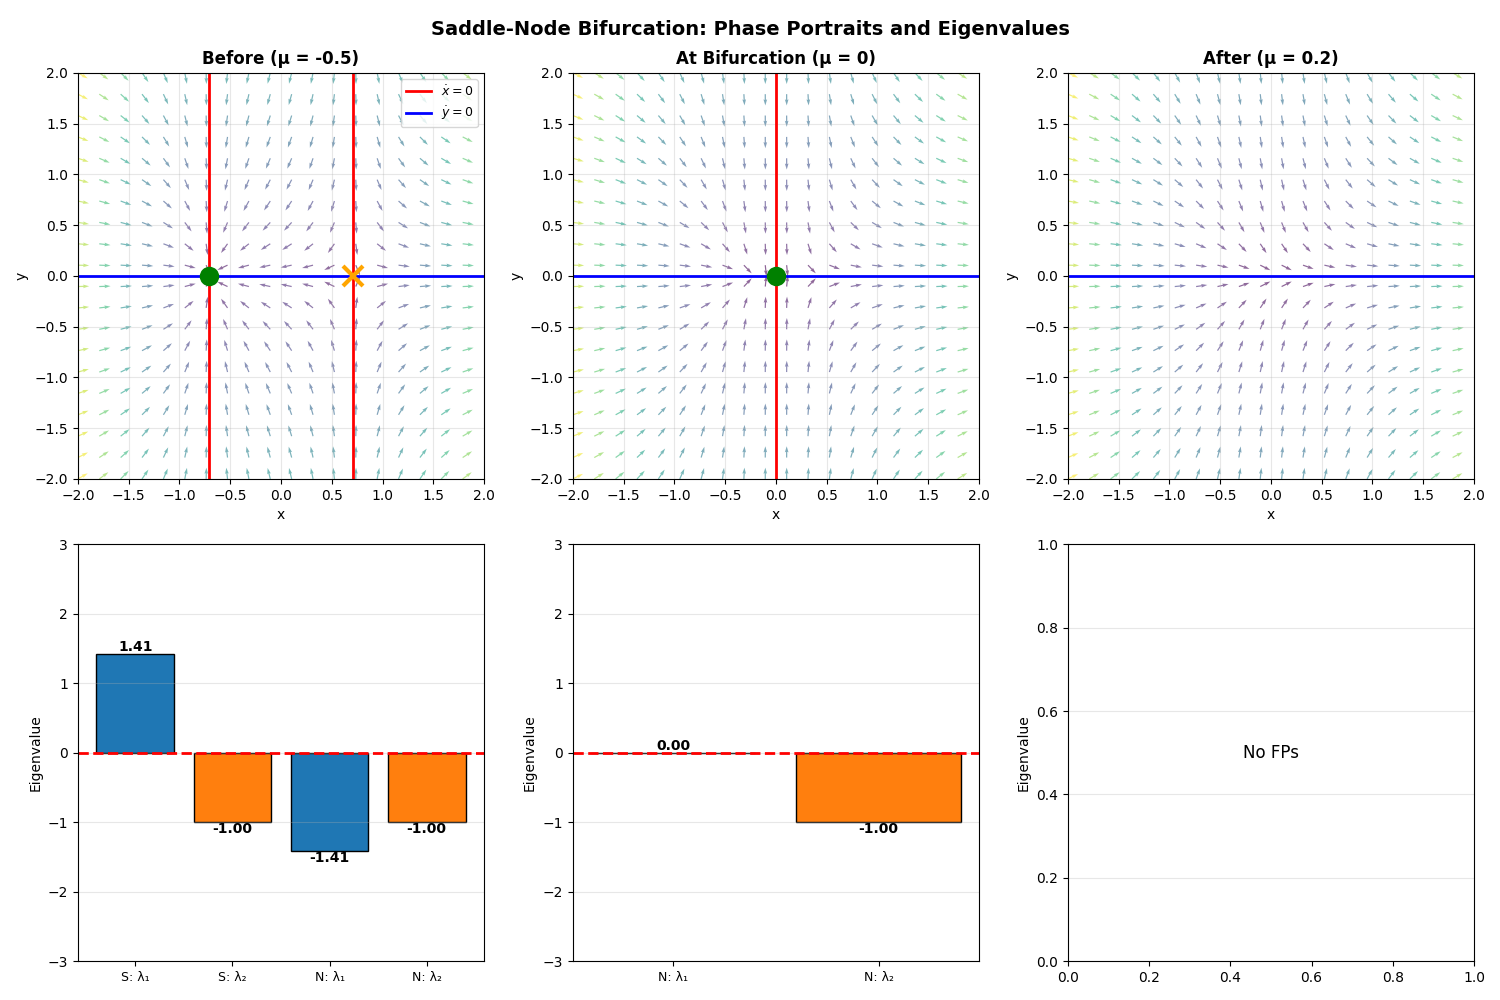

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

mu_values = [-0.5, 0.0, 0.2]
titles = ['Before (μ = -0.5)', 'At Bifurcation (μ = 0)', 'After (μ = 0.2)']

for col, (mu, title) in enumerate(zip(mu_values, titles)):
    
    # === Top row: Phase portrait ===
    ax = axes[0, col]
    
    x_range = np.linspace(-2, 2, 20)
    y_range = np.linspace(-2, 2, 20)
    X, Y = np.meshgrid(x_range, y_range)
    DX, DY = vector_field(X, Y, mu)
    
    magnitude = np.sqrt(DX**2 + DY**2)
    magnitude[magnitude == 0] = 1
    DX_norm = DX / magnitude
    DY_norm = DY / magnitude
    
    ax.quiver(X, Y, DX_norm, DY_norm, magnitude, cmap='viridis', alpha=0.6)
    
    # Nullclines
    if mu <= 0:
        x_null = np.sqrt(-mu)
        ax.axvline(x_null, color='red', linewidth=2, label=r'$\dot{x}=0$')
        if x_null > 0:
            ax.axvline(-x_null, color='red', linewidth=2)
    
    ax.axhline(0, color='blue', linewidth=2, label=r'$\dot{y}=0$')
    
    # Fixed points
    fps = find_fixed_points(mu)
    for (x_fp, y_fp) in fps:
        eigs = jacobian_eigenvalues(x_fp)
        if eigs[0] * eigs[1] < 0:
            ax.plot(x_fp, y_fp, 'x', markersize=15, color='orange', markeredgewidth=3)
        else:
            ax.plot(x_fp, y_fp, 'o', markersize=12, color='green', markeredgewidth=2)
    
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    if col == 0:
        ax.legend(loc='upper right', fontsize=9)
    
    # === Bottom row: Eigenvalues ===
    ax2 = axes[1, col]
    
    if len(fps) > 0:
        all_eigs = []
        labels = []
        colors_bar = []
        
        for i, (x_fp, _) in enumerate(fps):
            eigs = jacobian_eigenvalues(x_fp)
            all_eigs.extend(eigs)
            fp_type = 'S' if eigs[0] * eigs[1] < 0 else 'N'
            labels.extend([f'{fp_type}: λ₁', f'{fp_type}: λ₂'])
            colors_bar.extend(['tab:blue', 'tab:orange'])
        
        x_pos = np.arange(len(all_eigs))
        bars = ax2.bar(x_pos, all_eigs, color=colors_bar, edgecolor='black')
        
        for bar, eig in zip(bars, all_eigs):
            height = bar.get_height()
            va = 'bottom' if height >= 0 else 'top'
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{eig:.2f}', ha='center', va=va, fontsize=10, fontweight='bold')
        
        ax2.axhline(0, color='red', linewidth=2, linestyle='--')
        ax2.set_xticks(x_pos)
        ax2.set_xticklabels(labels, fontsize=9)
        ax2.set_ylim(-3, 3)
    else:
        ax2.text(0.5, 0.5, 'No FPs', transform=ax2.transAxes, ha='center', va='center', fontsize=12)
    
    ax2.set_ylabel('Eigenvalue')
    ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Saddle-Node Bifurcation: Phase Portraits and Eigenvalues', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()